In [ ]:
import torch
import torch.nn as nn

In [ ]:
class LinearAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Input N, 784
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128), # N, 784 -> N, 128
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3), # -> N, 3
        )

        self.decoder = nn.Sequential(
            nn.Linear(3,12),
            nn.ReLU(),
            nn.Linear(12,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,28*28),
            # Our images have values between 0 and 1, 
            # so our activation should map to 0,1 -> sigmoid
            nn.Sigmoid(),
        )

    def forward(self, x):
        enc = self.encoder(x)
        dec = self.decoder(enc)
        return dec
    
    

In [ ]:
class CNNAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Input N, 1, 28, 28
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), # N, 16, 14, 14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # N, 32, 7, 7
            nn.ReLU(),
            nn.Conv2d(32, 64, 7) # N, 64, 1, 1
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # N, 16, 14, 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), # N, 1, 28, 28,
            nn.Sigmoid()
        )

    def forward(self, x):
        enc = self.encoder(x)
        dec = self.decoder(enc)
        return dec
# nn.MaxPool2d - Revert: nn.MaxUnpool2d

# VAE

In [ ]:
import torch
import torch.nn.functional as F
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, latent_dim, in_shape=(3,64,64)):
        super().__init__()
        self.latent_dim = latent_dim
        self.in_shape = in_shape
        
        # -- ENCODER --
        # Input:  N, 3, 64, 64
        # Output: N, 2*latent_dim (mu, log_sigma)
        self.encoder = nn.Sequential(
            nn.Conv2d(self.in_shape[0], 32, 4, stride=2), # -> N, 32, 31, 31
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), # -> N, 64, 14, 14
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2), # -> N,128,6,6
            nn.ReLU(),
            nn.Conv2d(128, 256,4, stride=2), # -> N,256,2,2
            nn.ReLU(),
            nn.Flatten(start_dim=1), # N, 256*2*2 = 1024
            nn.Linear(256*2*2, 2*self.latent_dim), # N,1024 -> N, 2*latent_dim
        )

        # -- DECODER --
        # Input: N, latent_dim
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256*2*2), # (N, 256*2*2)
            nn.Unflatten(1, (1024, 1, 1)), # (N, 1024, 1, 1)
            nn.ConvTranspose2d(1024, 128, 5, stride=2), # -> (N, 128, 5, 5)
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 5, stride=2), # -> N, 64, 13, 13
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 6, stride=2), # -> N, 32, 30, 30
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 6, stride=2), # -> N, 3, 64, 64
            nn.Sigmoid()
        )

    def forward(self, x):
        # encoder
        mu, log_var = torch.split(self.encoder(x), self.latent_dim, dim=1) # (N, latent_dim), (N, latent_dim)

        # reparameterization trick
        eps = torch.randn_like(log_var)
        z = mu + torch.exp(0.5 * log_var) * eps # -> latent_dim

        # decoder
        recon_x =  self.decoder(z)

        return recon_x, mu, log_var
    
def vae_loss(recon_x, x, mu, log_var):
    reconstruction_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - torch.exp(log_var)) 
    loss = reconstruction_loss + kl_loss
    return loss

# train

In [ ]:
from torchvision import datasets, transforms


In [ ]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define a transform to resize images to 64x64
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Replace MNIST with CIFAR10
# Pass the 'transform' variable defined above, not the 'transforms' module
cifar_data = datasets.CIFAR10(root='cifar10', train=True, download=True, transform=transform)
data_loader = torch.utils.data.DataLoader(
    dataset=cifar_data, # Use the new dataset variable
    batch_size=64,
    shuffle=True,
)

dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))
# Check image shape (should have 3 channels for RGB)
print(images.shape)

In [ ]:
from data.dataset import CarRacingDataset
from torch.utils.data import DataLoader
import os
import sys

project_root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
sys.path.append(project_root)

dataset = CarRacingDataset(data_dir='../data/recorded_data')
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)

In [ ]:
import matplotlib.pyplot as plt
import torch
# Get one batch from the dataloader
dataiter = iter(dataloader)
images = next(dataiter)

# Print image shape and value ranges
print(f"Image batch shape: {images.shape}")
print(f"Image value range: min={torch.min(images).item()}, max={torch.max(images).item()}")

# Display a few images from the batch
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    # If images are in [0,1] and have 3 channels (RGB)
    if images.shape[1] == 3:
        # Convert from CxHxW to HxWxC for matplotlib
        img = images[i].permute(1, 2, 0)
        axes[i].imshow(img)
    else:
        axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Sample {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VAE(latent_dim=32)
optim = torch.optim.Adam(params=model.parameters(), lr=1e-2)

# params
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

In [ ]:
single_batch = next(iter(dataloader)).to(device)
print(f"Batch shape: {single_batch.shape}")

In [ ]:
from tqdm import tqdm

# overfit a single batch
single_batch = next(iter(dataloader)).to(device)
print(f'Single batch shape: {single_batch.shape}')


# -- Hyperparameters --
n_epochs = 1000
outputs = []
losses = []

# --- Training Loop ---
for epoch in tqdm(range(n_epochs)):
    # print(f'Epoch :{epoch+1}/{n_epochs}')

    # for i, img in enumerate(dataloader): # iterate batches

    img = img.to(device)

    recon_x, mu, log_var = model(single_batch)
    loss = vae_loss(recon_x, single_batch, mu, log_var)
    print(f'loss: {loss}')

    optim.zero_grad()
    loss.backward()
    optim.step()

    # losses
    losses.append(loss.item())

    # Store results from the first batch of each epoch for visualization
    if epoch % 50 == 0 or epoch == n_epochs - 1:
        outputs.append((epoch, single_batch.detach().cpu(), recon_x.detach().cpu()))
        print(f'Epoch {epoch+1}, Loss: {loss.item():.6f}')

# visualize

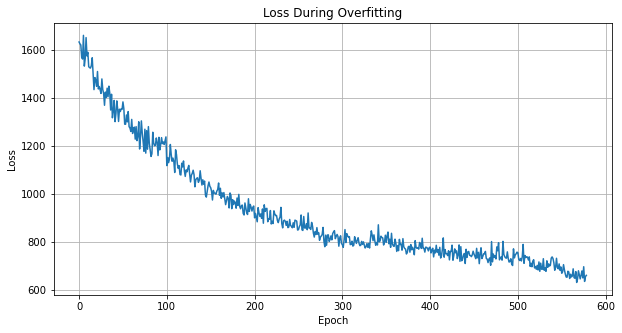

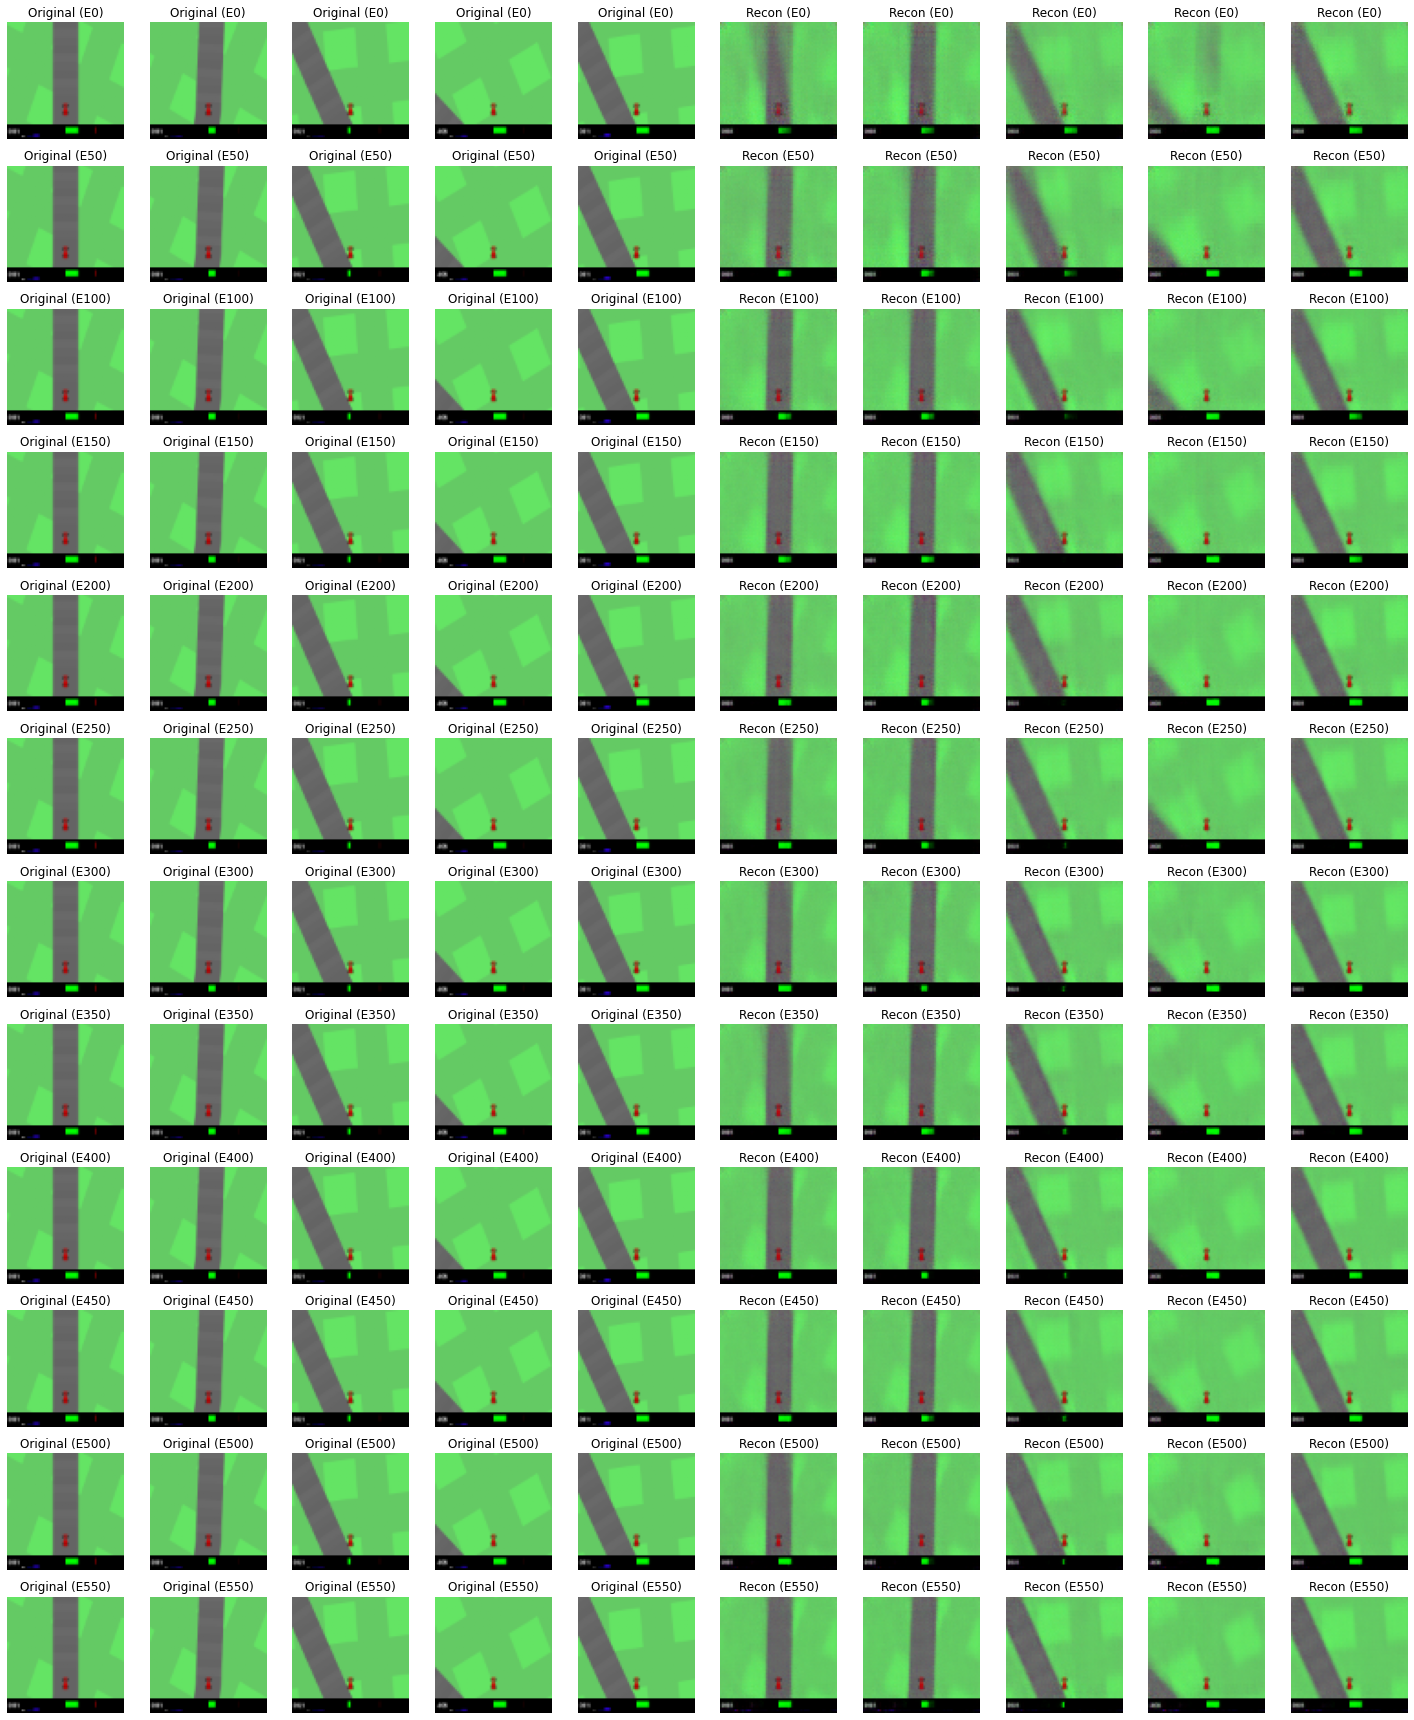

In [65]:
# Plot the loss curve
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('Loss During Overfitting')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Visualize original vs reconstructed images to see overfitting progress
def show_progress(outputs, num_images=5):
    fig, axes = plt.subplots(len(outputs), 2*num_images, figsize=(20, 2*len(outputs)))
    
    for i, (epoch, original, recon) in enumerate(outputs):
        for j in range(num_images):
            # Original images
            if len(original.shape) == 4:  # If batched images (B,C,H,W)
                img = original[j].permute(1, 2, 0).numpy()
                if img.shape[2] == 1:  # If grayscale
                    img = img.squeeze(-1)
            else:
                img = original[j].numpy()
                
            axes[i, j].imshow(img, cmap='gray' if len(img.shape) == 2 else None)
            axes[i, j].set_title(f'Original (E{epoch})')
            axes[i, j].axis('off')
            
            # Reconstructed images
            if len(recon.shape) == 4:  # If batched images
                rec_img = recon[j].permute(1, 2, 0).numpy()
                if rec_img.shape[2] == 1:  # If grayscale
                    rec_img = rec_img.squeeze(-1)
            else:
                rec_img = recon[j].numpy()
                
            axes[i, j+num_images].imshow(rec_img, cmap='gray' if len(rec_img.shape) == 2 else None)
            axes[i, j+num_images].set_title(f'Recon (E{epoch})')
            axes[i, j+num_images].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show overfitting progress
show_progress(outputs)